# Task 2.2.3: Image Pre-processing for Deep Learning-Based Object Detection
## Techniques for pre-processing images for deep learning-based object detection, including Resizing, Normalization, and Data Augmentation

In [1]:
# Importing required libraries, which include:
# OpenCV library used for the many tasks in computer vision, from loading images, to processing, detecting, shapes, tracking objects etc.:
import cv2
# Numpy is very useful computation library, here we can use it to compute means:
import numpy as np
# We need the following to show images as plots (x and y axes), later we will use it to draw actual plots too:
import matplotlib.pyplot as plt
# We need the following to draw areas of interest on our plots and images:
import matplotlib.patches as patches

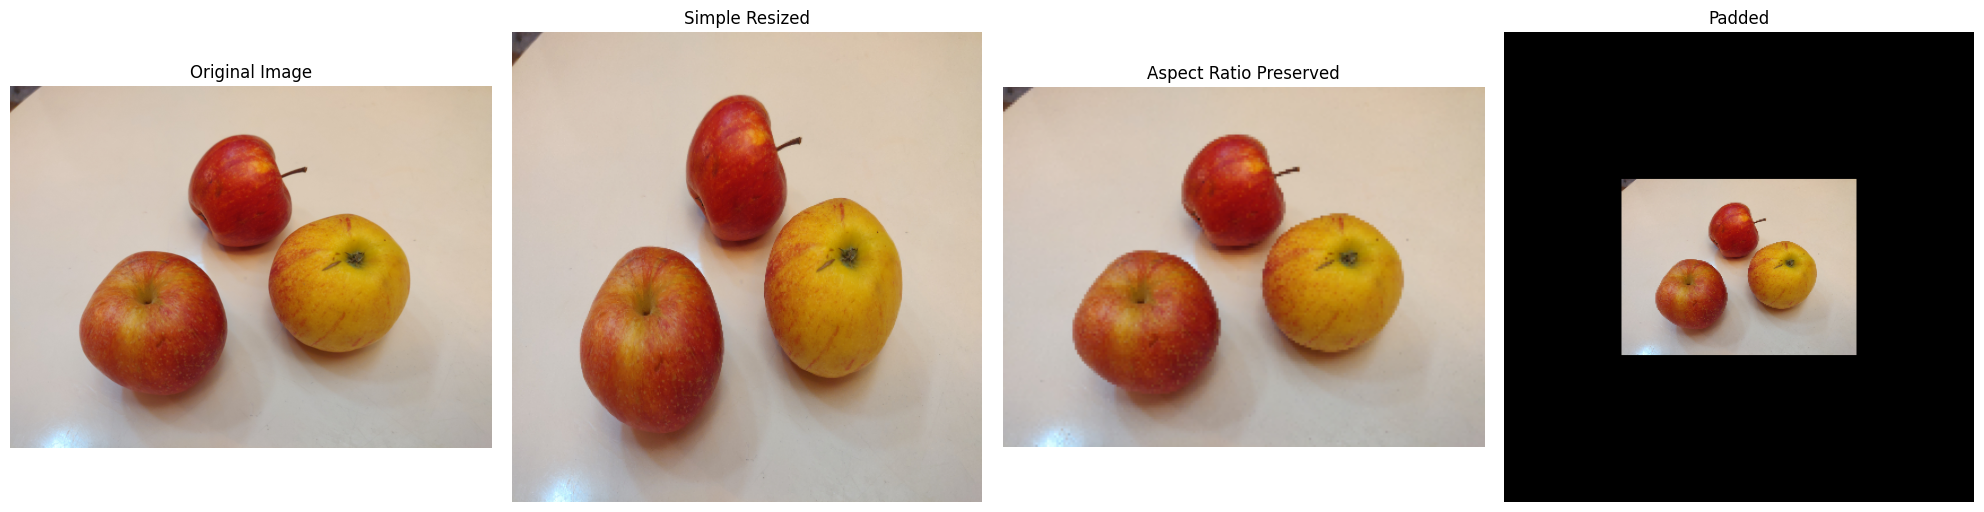

In [2]:
# Preserving Aspect Ratio: This involves resizing the image such that its aspect ratio remains unchanged. After resizing, padding might be required to achieve the target size:
def resize_preserve_aspect(image, target_size=(208,208)):
    h, w, _ = image.shape
    scale = min(target_size[0] / h, target_size[1] / w)
    new_h, new_w = int(h * scale), int(w * scale)
    
    resized_image = cv2.resize(image, (new_w, new_h))
    return resized_image

# Padding: After resizing to preserve the aspect ratio, the image might not match the target dimensions. Padding can be applied to fill the remaining space, often with zeros (black) or another chosen value.:
def pad_image(image, target_size=(416,416)):
    h, w, _ = image.shape
    top_pad, bottom_pad = (target_size[1] - h) // 2, target_size[1] - h - (target_size[1] - h) // 2
    left_pad, right_pad = (target_size[0] - w) // 2, target_size[0] - w - (target_size[0] - w) // 2
    
    padded_image = cv2.copyMakeBorder(image, top_pad, bottom_pad, left_pad, right_pad, cv2.BORDER_CONSTANT)
    return padded_image

# Simple Resizing: The image is resized directly to the target dimensions without preserving the aspect ratio. This can distort the image but is computationally simpler.
def simple_resize(image, target_size=(416,416)):
    return cv2.resize(image, target_size)

# Load the image
image_path = "./imageset/apples3.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB for matplotlib

# Applying all the resizing methods
simple_resized = simple_resize(image)
aspect_preserved = resize_preserve_aspect(image)
padded = pad_image(aspect_preserved)

# Displaying the results
fig, axs = plt.subplots(1, 4, figsize=(20,5))

axs[0].imshow(image)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(simple_resized)
axs[1].set_title("Simple Resized")
axs[1].axis("off")

axs[2].imshow(aspect_preserved)
axs[2].set_title("Aspect Ratio Preserved")
axs[2].axis("off")

axs[3].imshow(padded)
axs[3].set_title("Padded")
axs[3].axis("off")

plt.tight_layout()
plt.show()

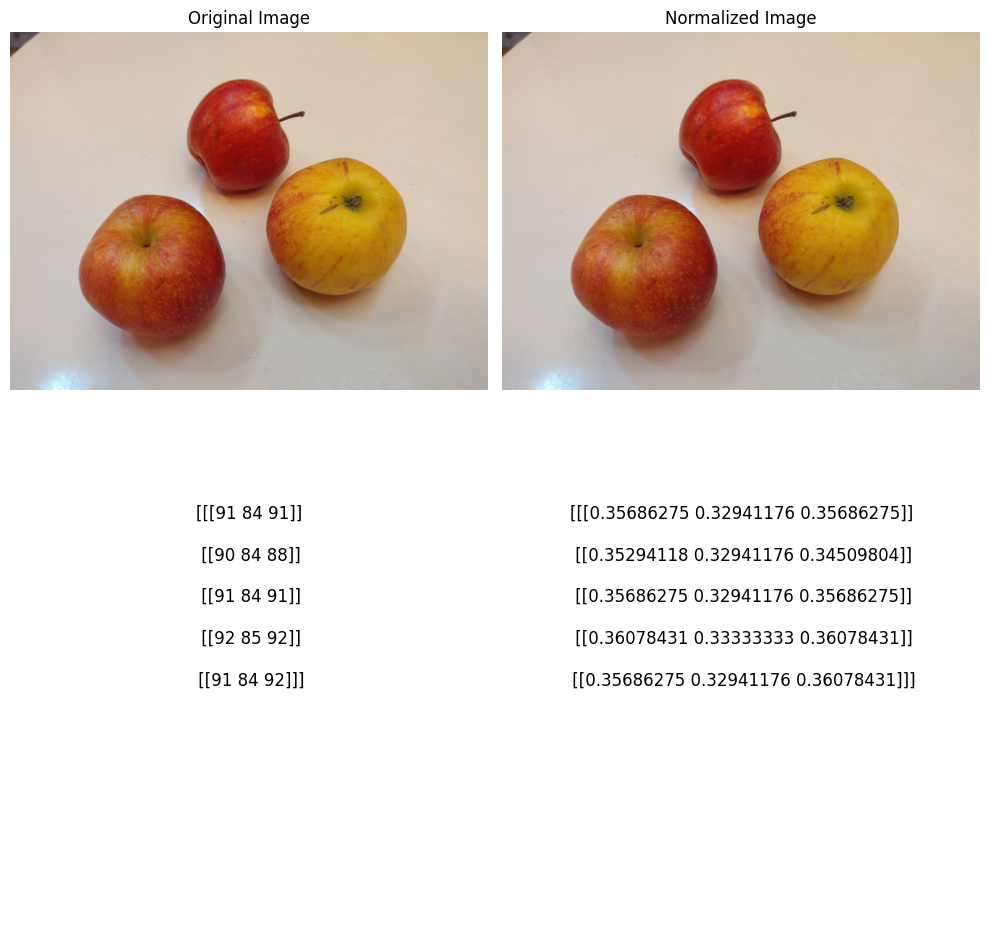

In [3]:
# Normalizing Image Pixel Values:
# Neural networks tend to perform better when their input data lies within a small range.
# Normalizing pixel values between 0 and 1 ensures a consistent range, improving training stability.

# Load the image
image_path = "./imageset/apples3.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB for matplotlib

# Normalize the image
normalized_image = image / 255.0

# Displaying the original and normalized images
fig, axs = plt.subplots(2, 2, figsize=(10,10))

# Original Image
axs[0, 0].imshow(image)
axs[0, 0].set_title("Original Image")
axs[0, 0].axis("off")

# Normalized Image
axs[0, 1].imshow(normalized_image)
axs[0, 1].set_title("Normalized Image")
axs[0, 1].axis("off")

# Printing pixel values for original image
axs[1, 0].axis("off")
axs[1, 0].text(0.5, 0.5, str(image[0:5, 0:1, :]), fontsize=12, ha='center')

# Printing pixel values for normalized image
axs[1, 1].axis("off")
axs[1, 1].text(0.5, 0.5, str(normalized_image[0:5, 0:1, :]), fontsize=12, ha='center')

plt.tight_layout()
plt.show()

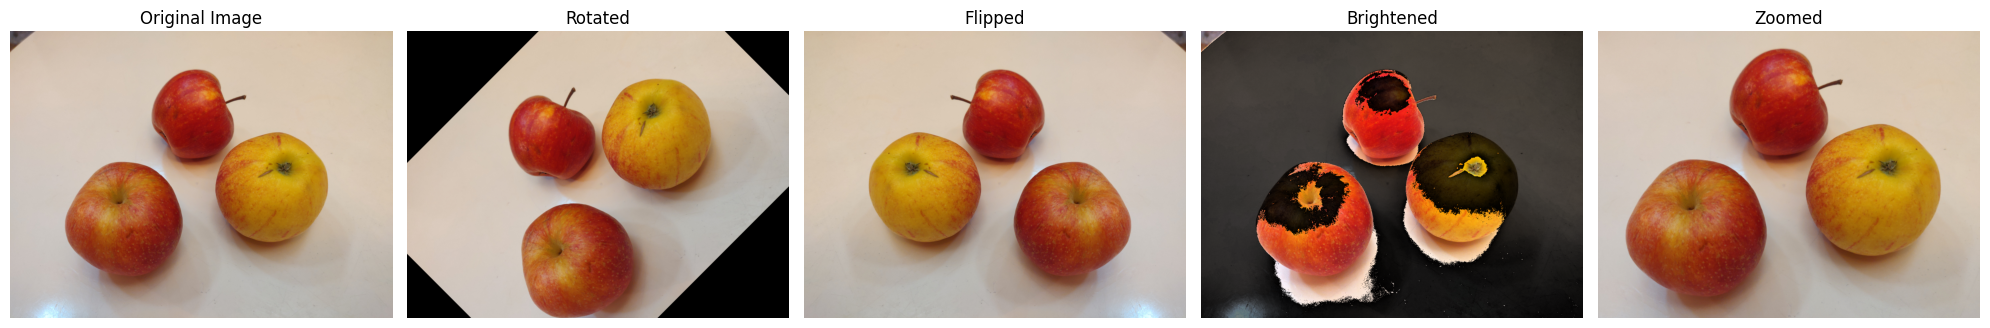

In [4]:
# Rotation: Rotating the image by a certain angle.
def rotate_image(image, angle):
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(image, M, (w, h))

# Flipping: Flipping the image either horizontally or vertically.
def flip_image(image, mode='horizontal'):
    if mode == 'horizontal':
        return cv2.flip(image, 1)
    elif mode == 'vertical':
        return cv2.flip(image, 0)

# Brightness Adjustments: Increasing or decreasing the brightness of the image.
def adjust_brightness(image, factor=1.0):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    hsv[:, :, 2] = hsv[:, :, 2] * factor
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

# Zooming: Cropping and resizing the image to simulate a zoomed effect.
def zoom_image(image, factor=1.2):
    h, w, _ = image.shape
    new_h, new_w = int(h / factor), int(w / factor)
    y_start, x_start = (h - new_h) // 2, (w - new_w) // 2
    cropped = image[y_start:y_start+new_h, x_start:x_start+new_w]
    return cv2.resize(cropped, (w, h))


# Example for testing augmentations:
image_path = "./imageset/apples3.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB for matplotlib

rotated = rotate_image(image, 45)
flipped = flip_image(image)
brightened = adjust_brightness(image, 1.5)
zoomed = zoom_image(image)

# Displaying results
fig, axs = plt.subplots(1, 5, figsize=(20,5))

axs[0].imshow(image)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(rotated)
axs[1].set_title("Rotated")
axs[1].axis("off")

axs[2].imshow(flipped)
axs[2].set_title("Flipped")
axs[2].axis("off")

axs[3].imshow(brightened)
axs[3].set_title("Brightened")
axs[3].axis("off")

axs[4].imshow(zoomed)
axs[4].set_title("Zoomed")
axs[4].axis("off")

plt.tight_layout()
plt.show()

Task 1: In real world object detection applications we will have a dataset of images to train our model on. In order to increase the amount of data we have and hence improve performance after training we must perform some augmentations on our images. Write a Python code snippet that will take all the images in the provided `imageset` dataset, perform a random augmentation on each and then save them into a new folder.

In [9]:
import os
import random
functions = [rotate_image, flip_image, adjust_brightness, zoom_image]

def random_augment_images(input_folder, output_folder):
    for filename in os.listdir(input_folder):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            image_path = os.path.join(input_folder, filename)
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Randomly select an augmentation function
            func = random.choice(functions)
            if (func == rotate_image):
                angle = random.choice([15, 30, 45, 60, 90])
                augmented_image = func(image, angle)
            else:
                augmented_image = func(image)
            
            # Save the augmented image
            output_path = os.path.join(output_folder, filename)
            cv2.imwrite(output_path, cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR))
    return

# Run the function
input_folder = "./imageset/"
output_folder = "./preprocessedimageset/"
random_augment_images(input_folder, output_folder)

Encoded Bounding Box: [168.25, 124.5, 5.0106352940962555, 5.090678001769792]


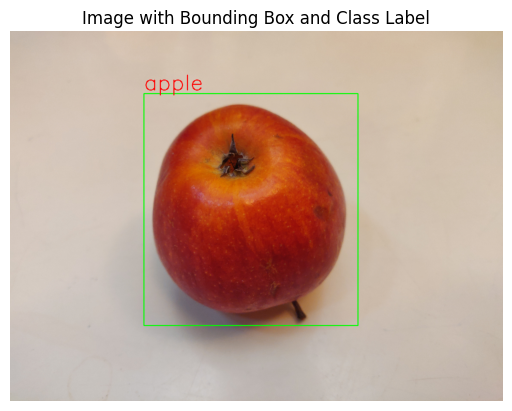

In [10]:
from math import log

# Define the encode function for bounding boxes relative to anchor boxes
def encode_box(box, anchor):
    '''
    box: a list of format [x_center, y_center, width, height]
    anchor: a list of format [anchor_width, anchor_height]
    Returns the encoded box offsets.
    '''
    encoded_box = [(box[0] - anchor[0]/2)/anchor[0], (box[1] - anchor[1]/2)/anchor[1], 
                   log(box[2]/anchor[0]), log(box[3]/anchor[1])]
    return encoded_box

# Hardcoded bounding box data
x_center, y_center, width, height = 675, 500, 600, 650  # Example coordinates
bounding_box = [x_center - width/2, y_center - height/2, x_center + width/2, y_center + height/2]

# Hardcoded class label
class_label = "apple"

# Assuming a predefined anchor box for demonstration purposes
anchor = [4, 4]  # Example anchor dimensions

# Encode the bounding box
encoded_bounding_box = encode_box([x_center, y_center, width, height], anchor)
print(f"Encoded Bounding Box: {encoded_bounding_box}")

# Load a local image
image_path = "./imageset/apple.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Draw the bounding box and display class label on the image
cv2.rectangle(image, (int(bounding_box[0]), int(bounding_box[1])), (int(bounding_box[2]), int(bounding_box[3])), (0, 255, 0), 2)
cv2.putText(image, class_label, (int(bounding_box[0]), int(bounding_box[1]-10)), cv2.FONT_HERSHEY_SIMPLEX, 2.0, (255, 0, 0), 2)

# Show the image
plt.figure()
plt.imshow(image)
plt.title("Image with Bounding Box and Class Label")
plt.axis("off")
plt.show()

**Bonus Task:** Create a Python script to automatically process all images in your dataset or the provided imageset and encode the correct ground truth bounding boxes. Encoding, labeling and correctly preparing all ground truth data is a tedious task that cannot be done automatically, but using helpful algorithms we can make the task easier and speed up the process.

In [2]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Source directory
src_directory = './imageset/'

# Destination directories
train_directory = './train/'
val_directory = './validate/'
test_directory = './test/'

# Create destination directories if they don't exist
os.makedirs(train_directory, exist_ok=True)
os.makedirs(val_directory, exist_ok=True)
os.makedirs(test_directory, exist_ok=True)

# Get all files from the source directory
all_files = [f for f in os.listdir(src_directory) if os.path.isfile(os.path.join(src_directory, f))]

# Split files into training, validation, and test
train_files, temp_files = train_test_split(all_files, test_size=0.3, random_state=42)
val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

# Function to move files to their respective directories
def move_files(files, dest_directory):
    for f in files:
        shutil.copy(os.path.join(src_directory, f), os.path.join(dest_directory, f))

# Move the files
move_files(train_files, train_directory)
move_files(val_files, val_directory)
move_files(test_files, test_directory)